In [1]:
from scipy.spatial.distance import cdist, pdist, squareform
import numpy as np

In [6]:
X = np.random.rand(50, 10)

D = squareform(pdist(X, metric = 'euclidean'))

# print(X)
# print(D)

X_test = np.random.rand(10, 10)
D_cross = cdist(X_test, X, metric = 'euclidean')

k = 5
knn_indices = np.argsort(D_cross, axis = 1)[:, :k]

print(knn_indices)

[[32  6 38 41 35]
 [ 5 40  4 36 30]
 [ 4 22 23 28 41]
 [17 21  1  7 19]
 [19 15 36 27 49]
 [44  5  8 34 49]
 [12 22 26 40 48]
 [ 5 22 47 14 40]
 [ 2 22  3 27 48]
 [41 22 20  5  4]]


In [9]:
a, b = np.random.rand(5, 8), np.random.rand(3, 8)

metrics = [
    'euclidean',    # standard geometric distance
    'cosine',       # angle-based — great for embeddings/NLP
    'manhattan',    # L1, robust to outliers
    'chebyshev',    # max along any dimension
    'minkowski',    # generalizes euclidean/manhattan (param p)
    'mahalanobis',  # accounts for feature covariance
    'hamming',      # fraction of differing bits — for binary data
    'jaccard',      # set overlap — for binary/sparse vectors
    'correlation',  # Pearson correlation distance
    'canberra',     # weighted L1, sensitive to near-zero values
]

for m in metrics:
    try:
        D = cdist(a, b, metric = m)
        print(f"{m:15} = {D}")
    except:
        print(f"{m} needs extra params")

euclidean       = [[0.83772621 0.72431225 0.85983796]
 [1.52197886 1.19852573 1.67285793]
 [0.93595653 0.79230432 0.91069804]
 [0.99843271 0.80502661 1.12972346]
 [1.56334584 1.15835547 1.46022571]]
cosine          = [[0.08743088 0.09403894 0.16348434]
 [0.31330619 0.20952342 0.49686976]
 [0.11850019 0.10284969 0.17134789]
 [0.10400474 0.21624828 0.36015844]
 [0.36633529 0.30984536 0.47331648]]
manhattan needs extra params
chebyshev       = [[0.47502656 0.49888503 0.55336755]
 [0.89545507 0.81939586 0.84788069]
 [0.47582611 0.63516563 0.56616865]
 [0.6998179  0.49046867 0.65017348]
 [0.76697706 0.79153407 0.8200189 ]]
minkowski       = [[0.83772621 0.72431225 0.85983796]
 [1.52197886 1.19852573 1.67285793]
 [0.93595653 0.79230432 0.91069804]
 [0.99843271 0.80502661 1.12972346]
 [1.56334584 1.15835547 1.46022571]]
mahalanobis needs extra params
hamming         = [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
jaccard         = [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

## Basic

## Optimization

In [11]:
from scipy.optimize import minimize

def f(x):
    return (x-3)**2

res = minimize(f, 2)
res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 5.551437397369767e-17
        x: [ 3.000e+00]
      nit: 2
      jac: [-4.325e-13]
 hess_inv: [[ 5.000e-01]]
     nfev: 6
     njev: 3

In [13]:
res.x[0]

2.999999992549203

In [16]:
f = lambda x: (x[0] - 1)**2 + (x[1] - 2.5)**2

cons = ({'type':'ineq', 'fun': lambda x: x[0] - 2*x[1] + 2},
       {'type':'ineq', 'fun': lambda x: -x[0] - 2*x[1] + 6},
       {'type':'ineq', 'fun': lambda x: -x[0] + 2*x[1] + 2})
bnds = ((0, None), (0, None))

res = minimize(f, (2, 0), bounds = bnds, constraints = cons)
res

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.8000000011920985
       x: [ 1.400e+00  1.700e+00]
     nit: 3
     jac: [ 8.000e-01 -1.600e+00]
    nfev: 10
    njev: 3

In [17]:
res.x

array([1.4, 1.7])

## Interpolation

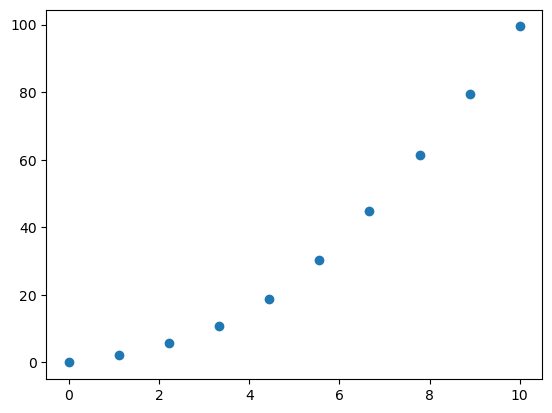

In [20]:
from scipy.interpolate import interp1d

x = np.linspace(0, 10, 10)
y = x**2 + np.sin(x)
plt.scatter(x, y)

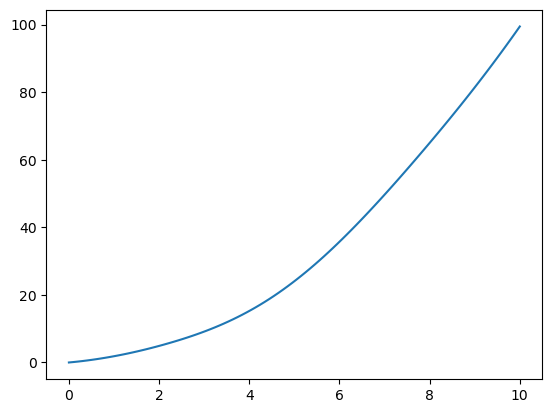

In [25]:
f = interp1d(x, y, kind = 'cubic')

x_dense = np.linspace(0, 10, 100)
y_dense = f(x_dense)

plt.plot(x_dense, y_dense)

## Curve Fitting

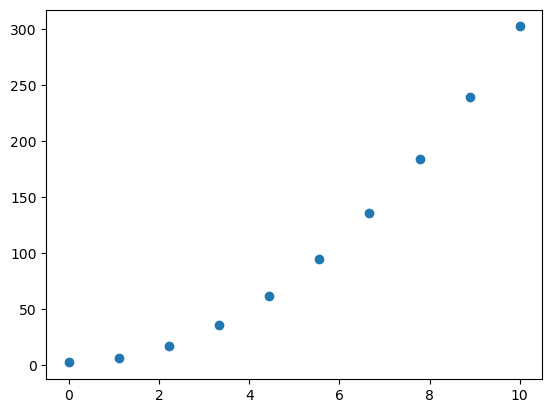

In [26]:
x_data = np.linspace(0, 10, 10)
y_data = 3*x_data**2 + 2

plt.scatter(x_data, y_data)

In [27]:
from scipy.optimize import curve_fit

def func(x, a, b):
    return a*x**2 + b

popt, pcov = curve_fit(func, x_data, y_data, p0 = (1, 1))

popt

array([3., 2.])

In [29]:
curve_fit?

Signature:
curve_fit(
    f,
    xdata,
    ydata,
    p0=None,
    sigma=None,
    absolute_sigma=False,
    check_finite=True,
    bounds=(-inf, inf),
    method=None,
    jac=None,
    *,
    full_output=False,
    **kwargs,
)
Docstring:
Use non-linear least squares to fit a function, f, to data.

Assumes ``ydata = f(xdata, *params) + eps``.

Parameters
----------
f : callable
    The model function, f(x, ...). It must take the independent
    variable as the first argument and the parameters to fit as
    separate remaining arguments.
xdata : array_like
    The independent variable where the data is measured.
    Should usually be an M-length sequence or an (k,M)-shaped array for
    functions with k predictors, and each element should be float
    convertible if it is an array like object.
ydata : array_like
    The dependent data, a length M array - nominally ``f(xdata, ...)``.
p0 : array_like, optional
    Initial guess for the parameters (length N). If None, then the
    initia